In [35]:
import csv
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

## Rezolvarea problemei cu tool cu 2 parametrii

#### Pasul 1 - plot pt distributia datelor & plot pt “verificarea” liniaritatii (daca legatura intre y si x e una liniara)

In [36]:
def loadData(fileName, inputVariableName1, inputVariableName2, outputVariableName):
    data = []
    dataNames = []

    with open(fileName) as csv_file: # deschidem csv-ul
        csv_reader = csv.reader(csv_file, delimiter=',') # citim datele din csv
        line_count = 0 # suntem pe prima linie
        for row in csv_reader:
            if line_count == 0: # daca suntem pe prima linie, atunci inseamna ca suntem pe headerul tabelului
                dataNames = row # salvam numele coloanelor
            else: # daca nu suntem pe prima linie, atunci salvam datele de pe randul curent
                data.append(row)
            line_count += 1

        idx1 = dataNames.index(inputVariableName1)
        idx2 = dataNames.index(inputVariableName2)
        idxOutput = dataNames.index(outputVariableName)
        inputs1 = [float(row[idx1]) for row in data]
        inputs2 = [float(row[idx2]) for row in data]
        outputs = [float(row[idxOutput]) for row in data]

    return inputs1, inputs2, outputs

In [37]:
crtDir = os.getcwd() # luam calea catre folderul curent
filePath = os.path.join(crtDir, 'data', 'v2_world-happiness-report-2017.csv') # construim calea catre csv

inputs1, inputs2, outputs = loadData(filePath, 'Economy..GDP.per.Capita.', 'Freedom', 'Happiness.Score') # incarcam datele din csv
# inputs = normalizeData(inputs) # normalizam datele de intrare

print('input data: ', list(zip(inputs1, inputs2))[:5])
print('output data: ', outputs[:5])

input data:  [(1.616463184, 0.808231592), (1.482383013, 0.741191506), (1.48063302, 0.74031651), (1.564979553, 0.782489777), (1.443571925, 0.721785963)]
output data:  [7.537000179, 7.521999836, 7.504000187, 7.493999958, 7.468999863]


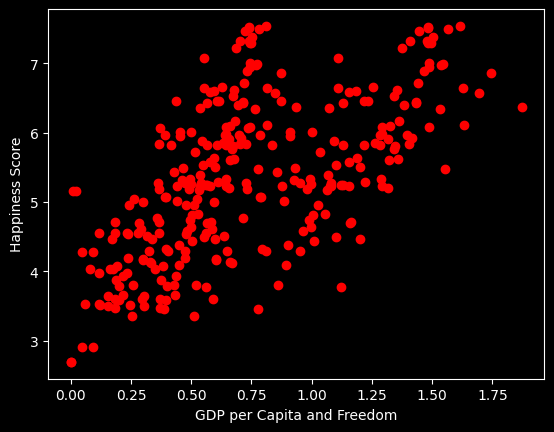

In [38]:
plt.plot(inputs1, outputs, 'ro') # afisam datele sub forma de puncte rosii
plt.plot(inputs2, outputs, 'ro') # afisam datele sub forma de puncte rosii
plt.xlabel('GDP per Capita and Freedom')
plt.ylabel('Happiness Score')
plt.show()


O clasificam intr-o problema de regresie liniara, deoarece se pare ca exista o legatura liniara intre cele doua variabile (se poate observa din plotul de mai sus).

<img src="images/regression.png" width="200">

#### Pasul 2 - impartire date pe train si validation

In [39]:
# Impartim datele pe train si validation (80% train, 20% validation)
np.random.seed(5)
indexes = [i for i in range(len(inputs1))]
trainSample = np.random.choice(indexes, int(0.8 * len(inputs1)), replace=False) # alegem aleator 80% din indexi pentru train
validationSample = [i for i in indexes if i not in trainSample] # restul de indexi vor fi pentru validation

trainInputs1 = [inputs1[i] for i in trainSample] # datele de intrare pentru train
trainInputs2 = [inputs2[i] for i in trainSample] # datele de intrare pentru train
trainOutputs = [outputs[i] for i in trainSample] # datele de iesire pentru train

validationInputs1 = [inputs1[i] for i in validationSample] # datele de intrare pentru validation
validationInputs2 = [inputs2[i] for i in validationSample] # datele de intrare pentru validation
validationOutputs = [outputs[i] for i in validationSample] # datele de iesire pentru validation

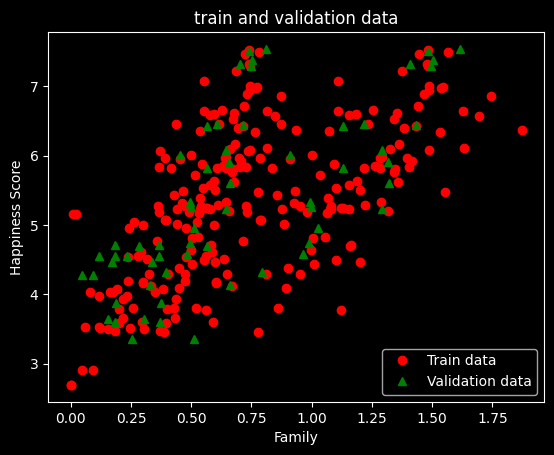

In [40]:
plt.plot(trainInputs1, trainOutputs, 'ro', label='Train data') # afisam datele de train sub forma de puncte rosii
plt.plot(trainInputs2, trainOutputs, 'ro') # afisam datele de train sub forma de puncte rosii
plt.plot(validationInputs1, validationOutputs, 'g^', label='Validation data') # afisam datele de validation sub forma de triunghiuri
# verzi
plt.plot(validationInputs2, validationOutputs, 'g^') # afisam datele de validation sub forma de triunghiuri verzi
plt.title('train and validation data')
plt.xlabel('Family')
plt.ylabel('Happiness Score')
plt.legend()
plt.show()

#### Pasul 3 - invatare model (cu tool generic si cu tool de least square)

In [41]:
# Antrenam modelul de regresie liniara folosind sklearn
# Sklearn are nevoie ca si input un training data care este de forma (noSamples x noFeatures array)
# In cazul nostru data o sa contina len(trainInputs) pentru linii, adica noSample si pentru noFeatures array o sa avem un vector cu un 2 elemente (GDP per Capita si Freedom)
sklearn_input = [[feature1, feature2] for feature1, feature2 in zip(trainInputs1, trainInputs2)]

regressor = linear_model.LinearRegression()
# pentru a gasi a si b sau w0 si w1 vom folosi functie de training care asteapta inputul pentru sklearn si outputurile cu care sa verifice predictia
regressor.fit(sklearn_input, trainOutputs)
w0 = regressor.intercept_
w1, w2 = regressor.coef_
print('The model learnt: y = ', w0, ' + ', w1, ' * GDP + ', w2, ' * Freedom')

The model learnt: y =  3.2007585998125503  +  -68609.8401290576  * GDP +  137223.98096701296  * Freedom


In [42]:
validationInputs = [[f1, f2] for f1, f2 in zip(validationInputs1, validationInputs2)]
computedValidationOutputs = regressor.predict(validationInputs)

#### Pasul 4 - calcul metrici de performanta (eroarea)

In [43]:
mean_abs_error = 0.0
for t1, t2 in zip(validationOutputs, computedValidationOutputs):
    mean_abs_error += abs(t1 - t2)
mean_abs_error /= len(validationOutputs)
print('mean absolute error:', mean_abs_error)

mean_squared_error = mean_squared_error(validationOutputs, computedValidationOutputs)
print('mean squared error (tool):  ', mean_squared_error)

mean absolute error: 0.5588276995980196
mean squared error (tool):   0.41421024311972354
